# Forecasting Sticker Sales

<img src="https://www.kaggle.com/competitions/85723/images/header">

## Dataset Description
For this challenge, you will be predicting multiple years worth of sales for various Kaggle-branded stickers from different fictitious stores in different (real!) countries. This dataset is completely synthetic, but contains many effects you see in real-world data, e.g., weekend and holiday effect, seasonality, etc.

**Files**

train.csv - the training set, which includes the sales data for each date-country-store-item combination.

test.csv - the test set; your task is to predict the corresponding item sales (num_sold) for each date-country-store-item combination. Note the Public leaderboard is scored on the first year of the data, and the Private on the remaining.

sample_submission.csv - a sample submission file in the correct forma

## Aim & Target 

**Aim**

The aim of this project is to develop a high-performance forecasting system capable of predicting daily sticker sales across international retail outlets. By leveraging a synthetic dataset derived from authentic business patterns, the goal is to build a model that captures the nuances of time-series data, such as yearly seasonality and regional consumer behavior. This project focuses on implementing advanced feature engineering and regression techniques to transform raw historical logs into actionable future insights. Ultimately, the objective is to create a robust pipeline that can accurately project demand for a full calendar year.

**Target**

The target variable is num_sold, which represents the total daily units sold for each unique combination of country, store, and product. The project specifically aims to minimize the Mean Absolute Percentage Error (MAPE), requiring a solution that stays accurate across both high-volume holiday peaks and standard sales days. Because the data spans multiple years, the target involves identifying and modeling complex temporal dependencies, including weekend effects and seasonal cycles. The final output is a precise, continuous numerical prediction for every required date in the forecasting horizon.

## Importing Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

## Reading Dataset & Dataframe Generation

In [2]:
df = pd.read_csv("/kaggle/input/competitions/playground-series-s5e1/train.csv") # We'll work on train data as our dataframe. 

test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s5e1/test.csv")

In [3]:
df.head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


## Exploratory Data Analysis

In [4]:
df.shape

(230130, 6)

In [5]:
df = df.drop('id', axis=1)

In [6]:
df.isnull().sum()

date           0
country        0
store          0
product        0
num_sold    8871
dtype: int64

In [7]:
test_df.shape

(98550, 5)

In [8]:
df.num_sold.unique()

array([  nan,  973.,  906., ..., 3446., 2266., 3996.])

In [9]:
df.num_sold.value_counts()

num_sold
5.0       1947
6.0       1703
16.0      1434
7.0       1382
15.0      1365
          ... 
4011.0       1
4126.0       1
3521.0       1
4699.0       1
4262.0       1
Name: count, Length: 4037, dtype: int64

In [10]:
df = df.dropna(subset=['num_sold'])

In [11]:
df.shape

(221259, 5)

In [12]:
df.columns

Index(['date', 'country', 'store', 'product', 'num_sold'], dtype='object')

In [13]:
df.country.value_counts()

country
Finland      38355
Italy        38355
Singapore    38355
Norway       38355
Canada       34109
Kenya        33730
Name: count, dtype: int64

In [14]:
df.store.value_counts()

store
Premium Sticker Mart    75684
Stickers for Less       74044
Discount Stickers       71531
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221259 entries, 1 to 230129
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      221259 non-null  object 
 1   country   221259 non-null  object 
 2   store     221259 non-null  object 
 3   product   221259 non-null  object 
 4   num_sold  221259 non-null  float64
dtypes: float64(1), object(4)
memory usage: 10.1+ MB


In [16]:
df['product'].value_counts()

product
Kaggle                46026
Kaggle Tiers          46026
Kerneler Dark Mode    46025
Kerneler              45962
Holographic Goose     37220
Name: count, dtype: int64

## Feature Engineering 

In [17]:
import pandas as pd
import numpy as np

def preprocess_data(data):
    # Convert date to datetime object
    data['date'] = pd.to_datetime(data['date'])
    
    # Extract temporal features
    data['year'] = data['date'].dt.year
    data['month'] = data['date'].dt.month
    data['day'] = data['date'].dt.day
    data['dayofweek'] = data['date'].dt.dayofweek
    
    # Create the "Weekend Effect" feature (Saturday=5, Sunday=6)
    data['is_weekend'] = data['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    
    # Drop the original date column as models cannot process it directly
    data = data.drop('date', axis=1)
    
    return data

# Apply to your existing df
df = preprocess_data(df)

In [18]:
# Convert categorical strings into numeric dummies
df = pd.get_dummies(df, columns=['country', 'store', 'product'], drop_first=True)

# Ensure all boolean columns (from get_dummies) are integers (0 or 1)
categorical_cols = df.select_dtypes(include=['bool']).columns
df[categorical_cols] = df[categorical_cols].astype(int)

In [19]:
import holidays

def add_holiday_features(df):
    # Create a column initialized to 0
    df['is_holiday'] = 0
    
    # List of unique countries in your data
    countries = {
        'Norway': 'NO',
        'Italy': 'IT',
        'Spain': 'ES',
        'Finland': 'FI',
        'Sweden': 'SE'
    }
    
    # Loop through each country and mark their specific holidays
    for country_name, country_code in countries.items():
        # Get the holiday list for that country across the years in our data
        country_holidays = holidays.CountryHoliday(country_code, years=[2017, 2018, 2019, 2020, 2021, 2022])
        
        # Mask for the specific country and the specific holiday dates
        country_mask = (df['country_' + country_name] == 1) if 'country_' + country_name in df.columns else (df['country'] == country_name)
        df.loc[country_mask & (df['date'].isin(country_holidays)), 'is_holiday'] = 1
        
    return df

## Model Development 

In [20]:
# 1. Define Features (X) and Target (y)
X = df.drop('num_sold', axis=1)
y = df['num_sold']

# 2. Time-based split (e.g., last 20% of data for validation)
split_index = int(len(df) * 0.8)

X_train, X_val = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_val = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Training shape: (177007, 16)
Validation shape: (44252, 16)


In [21]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Initialize the model
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)

# Fit the model
model.fit(X_train, y_train, 
          eval_set=[(X_val, y_val)], 
          verbose=100)

# Make predictions
preds = model.predict(X_val)

# Calculate MAPE
mape_score = mean_absolute_percentage_error(y_val, preds)
print(f"Validation MAPE: {mape_score:.4f}")

[0]	validation_0-rmse:573.30084
[100]	validation_0-rmse:104.59661
[200]	validation_0-rmse:90.47272
[300]	validation_0-rmse:88.93953
[400]	validation_0-rmse:89.36684
[500]	validation_0-rmse:89.19137
[600]	validation_0-rmse:89.02214
[700]	validation_0-rmse:89.24208
[800]	validation_0-rmse:89.06364
[900]	validation_0-rmse:88.91195
[999]	validation_0-rmse:88.49936
Validation MAPE: 0.1596


In [22]:
# Training with Log Transformation
model.fit(X_train, np.log1p(y_train), 
          eval_set=[(X_val, np.log1p(y_val))], 
          verbose=100)

# Back-transform predictions
log_preds = model.predict(X_val)
final_preds = np.expm1(log_preds)

# Recalculate MAPE
new_mape = mean_absolute_percentage_error(y_val, final_preds)
print(f"New Validation MAPE: {new_mape:.4f}")

[0]	validation_0-rmse:1.40165
[100]	validation_0-rmse:0.12533
[200]	validation_0-rmse:0.08786
[300]	validation_0-rmse:0.08421
[400]	validation_0-rmse:0.08250
[500]	validation_0-rmse:0.08186
[600]	validation_0-rmse:0.08112
[700]	validation_0-rmse:0.08098
[800]	validation_0-rmse:0.08105
[900]	validation_0-rmse:0.08107
[999]	validation_0-rmse:0.08111
New Validation MAPE: 0.0642


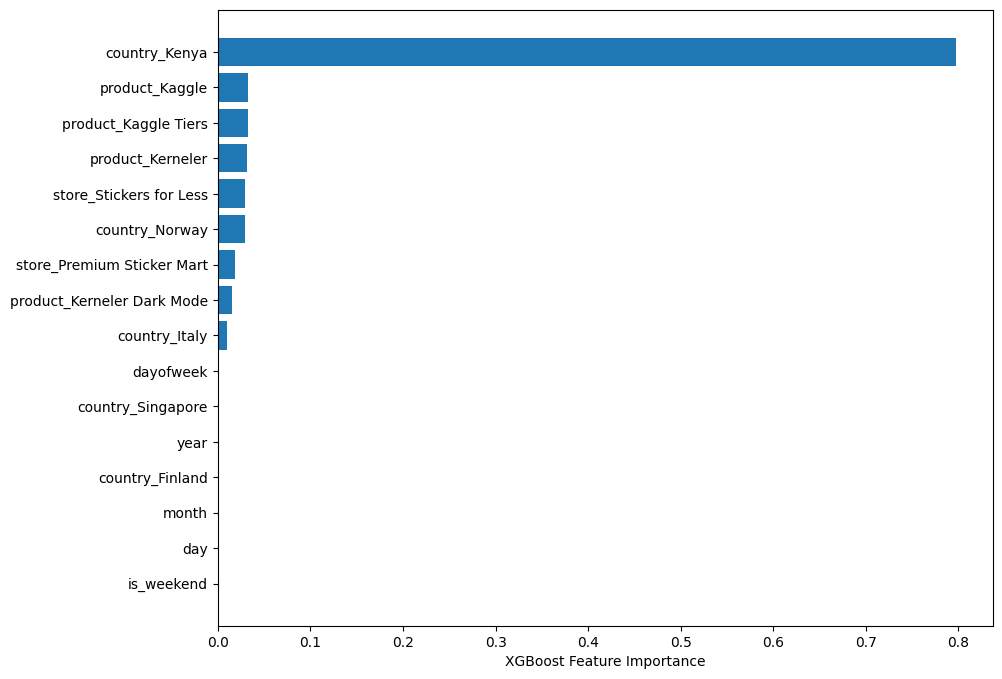

In [23]:
import matplotlib.pyplot as plt

# After model.fit()
plt.figure(figsize=(10, 8))
sorted_idx = model.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx], model.feature_importances_[sorted_idx])
plt.xlabel("XGBoost Feature Importance")
plt.show()

In [24]:
import joblib

# 1. Save the XGBoost model
model.save_model("model.ubj")

# 2. Save the column names (Crucial for the Streamlit app)
model_columns = list(X.columns)
joblib.dump(model_columns, "model_columns.pkl")

print("Files saved! You can now upload 'xgboost_model.json' and 'model_columns.pkl' to Hugging Face.")

Files saved! You can now upload 'xgboost_model.json' and 'model_columns.pkl' to Hugging Face.


In [25]:
from IPython.display import FileLink

display(FileLink('model.ubj'))
display(FileLink('model_columns.pkl'))

/kaggle/working/model.ubj

/kaggle/working/model_columns.pkl

## Kaggle Competition Submission

In [26]:
# 1. Load test data
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s5e1/test.csv')
test_id = test_df['id'] # Keep IDs for the submission file

# 2. Apply the same feature engineering
test_df = preprocess_data(test_df)

# 3. Handle categorical variables (One-Hot Encoding)
test_df = pd.get_dummies(test_df, columns=['country', 'store', 'product'], drop_first=True)

# 4. Ensure test_df has the EXACT same columns as X_train
# (Filling missing dummy columns with 0)
for col in model_columns:
    if col not in test_df.columns:
        test_df[col] = 0

# Reorder columns to match the training order
test_df = test_df[model_columns]
test_df[test_df.select_dtypes(include=['bool']).columns] = test_df.select_dtypes(include=['bool']).astype(int)

# 5. Predict (Remember to use expm1 to reverse the log!)
log_test_preds = model.predict(test_df)
final_test_preds = np.expm1(log_test_preds)

# 6. Create the submission file
submission = pd.DataFrame({
    'id': test_id,
    'num_sold': final_test_preds
})

submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' is ready!")

Submission file 'submission.csv' is ready!


In [27]:
from IPython.display import FileLink

display(FileLink('submission.csv'))

/kaggle/working/submission.csv